# BÀI THỰC HÀNH TUẦN 4: PHÂN TÍCH & DỰ BÁO CHUỖI THỜI GIAN
## PHƯƠNG PHÁP LUẬN DATA SCIENCE: TỪ DỮ LIỆU KHÍ HẬU ĐẾN MÔ HÌNH DỰ BÁO

> *"Chuỗi thời gian không chỉ là dữ liệu có thứ tự — nó mang trong mình ký ức quá khứ (Autocorrelation), nhịp đập mùa vụ (Seasonality), và chiều hướng dài hạn (Trend). Nhiệm vụ của nhà khoa học dữ liệu là tách bạch từng thành phần đó để dự báo tương lai."*

**Bộ dữ liệu:** [Daily Delhi Climate](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data) — Dữ liệu khí hậu hàng ngày tại thủ đô New Delhi, Ấn Độ (01/2013 – 04/2017).

**Biến mục tiêu dự báo:** `meantemp` — Nhiệt độ trung bình hàng ngày (°C).

**Mục tiêu bài thực hành:**
1. Nắm vững quy trình xử lý dữ liệu chuỗi thời gian (Time Series Data Pipeline).
2. Hiểu bản chất các thành phần Trend, Seasonality, Residual qua phép phân rã (Decomposition).
3. Kiểm định tính dừng (Stationarity) bằng ADF & KPSS — nền tảng lý thuyết cho mọi mô hình ARIMA.
4. Làm quen với các phương pháp trung bình trượt (Moving Average): SMA, CMA, EMA — để làm mượt chuỗi và quan sát xu hướng nền.
5. Xây dựng và so sánh các mô hình dự báo kinh điển: **ARIMA**, và chuỗi Exponential Smoothing tăng dần độ phức tạp — **Simple (SES) → Double/Holt → Triple/Holt-Winters**.
6. Đánh giá hiệu năng bằng các thước đo chuyên dụng cho chuỗi thời gian: MAE, RMSE, MAPE.

---
## 1. THIẾT LẬP MÔI TRƯỜNG & LOAD DỮ LIỆU

### 1.1. Import thư viện

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
np.seterr(all='ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện chuyên dụng cho chuỗi thời gian
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Thiết lập style biểu đồ
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print("Tất cả thư viện đã sẵn sàng!")

Tất cả thư viện đã sẵn sàng!


### 1.2. Load dữ liệu `DailyDelhiClimate`

Bộ dữ liệu gồm **1,462 bản ghi** (ngày) trong tập Train (01/2013 – 01/2017) và **114 bản ghi** trong tập Test (01/2017 – 04/2017), với 4 đặc trưng khí hậu:

| Cột | Ý nghĩa | Đơn vị |
|:---|:---|:---|
| `date` | Ngày quan sát | YYYY-MM-DD |
| `meantemp` | **Nhiệt độ trung bình** hàng ngày (Biến mục tiêu) | °C |
| `humidity` | Độ ẩm tương đối trung bình hàng ngày | % |
| `wind_speed` | Tốc độ gió trung bình hàng ngày | km/h |
| `meanpressure` | Áp suất khí quyển trung bình hàng ngày | hPa |

In [2]:
# Load dữ liệu
df_train_raw = pd.read_csv('../data/DailyDelhiClimateTrain.csv')
df_test_raw = pd.read_csv('../data/DailyDelhiClimateTest.csv')

# Chuyển đổi cột 'date' sang kiểu datetime và đặt làm Index
df_train_raw['date'] = pd.to_datetime(df_train_raw['date'])
df_test_raw['date'] = pd.to_datetime(df_test_raw['date'])

# Ghép 2 tập để có cái nhìn toàn cảnh, sau đó sẽ tách lại khi huấn luyện
df_raw = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
df_raw = df_raw.sort_values('date').reset_index(drop=True)
df_raw = df_raw.set_index('date')

# Train/Test giao nhau đúng 1 ngày (2017-01-01) -> giữ bản ghi đầu tiên (từ Train), bỏ bản trùng
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw.index.freq = 'D'  # Đặt tần suất Daily cho index

# Kiểm tra tổng quan
print(f"Kích thước tổng: {df_raw.shape}")
print(f"Phạm vi thời gian: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print(f"Tần suất: Hàng ngày (Daily)")
print()
display(df_raw.info())
print()
display(df_raw.describe().round(2))
display(df_raw.head())

Kích thước tổng: (1575, 4)
Phạm vi thời gian: 2013-01-01 → 2017-04-24
Tần suất: Hàng ngày (Daily)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1575 entries, 2013-01-01 to 2017-04-24
Freq: D
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1575 non-null   float64
 1   humidity      1575 non-null   float64
 2   wind_speed    1575 non-null   float64
 3   meanpressure  1575 non-null   float64
dtypes: float64(4)
memory usage: 61.5 KB


None

,meantemp,humidity,wind_speed,meanpressure
count,1575.00,1575.00,1575.00,1575.00
mean,25.23,60.43,6.90,1011.20
std,7.34,16.97,4.51,173.65
min,6.00,13.43,0.00,-3.04
25%,18.52,49.75,3.70,1001.88
50%,27.17,62.38,6.37,1009.11
75%,31.14,72.12,9.26,1015.20
max,38.71,100.00,42.22,7679.33


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


### 1.3. Trực quan hóa Khám phá Dữ liệu (Exploratory Data Analysis)

Bước đầu tiên khi phân tích chuỗi thời gian: **Nhìn tổng quan** toàn bộ chuỗi để nhận diện bằng mắt các đặc trưng cốt lõi: Xu hướng (Trend), Tính mùa vụ (Seasonality), và các bất thường (Anomalies).

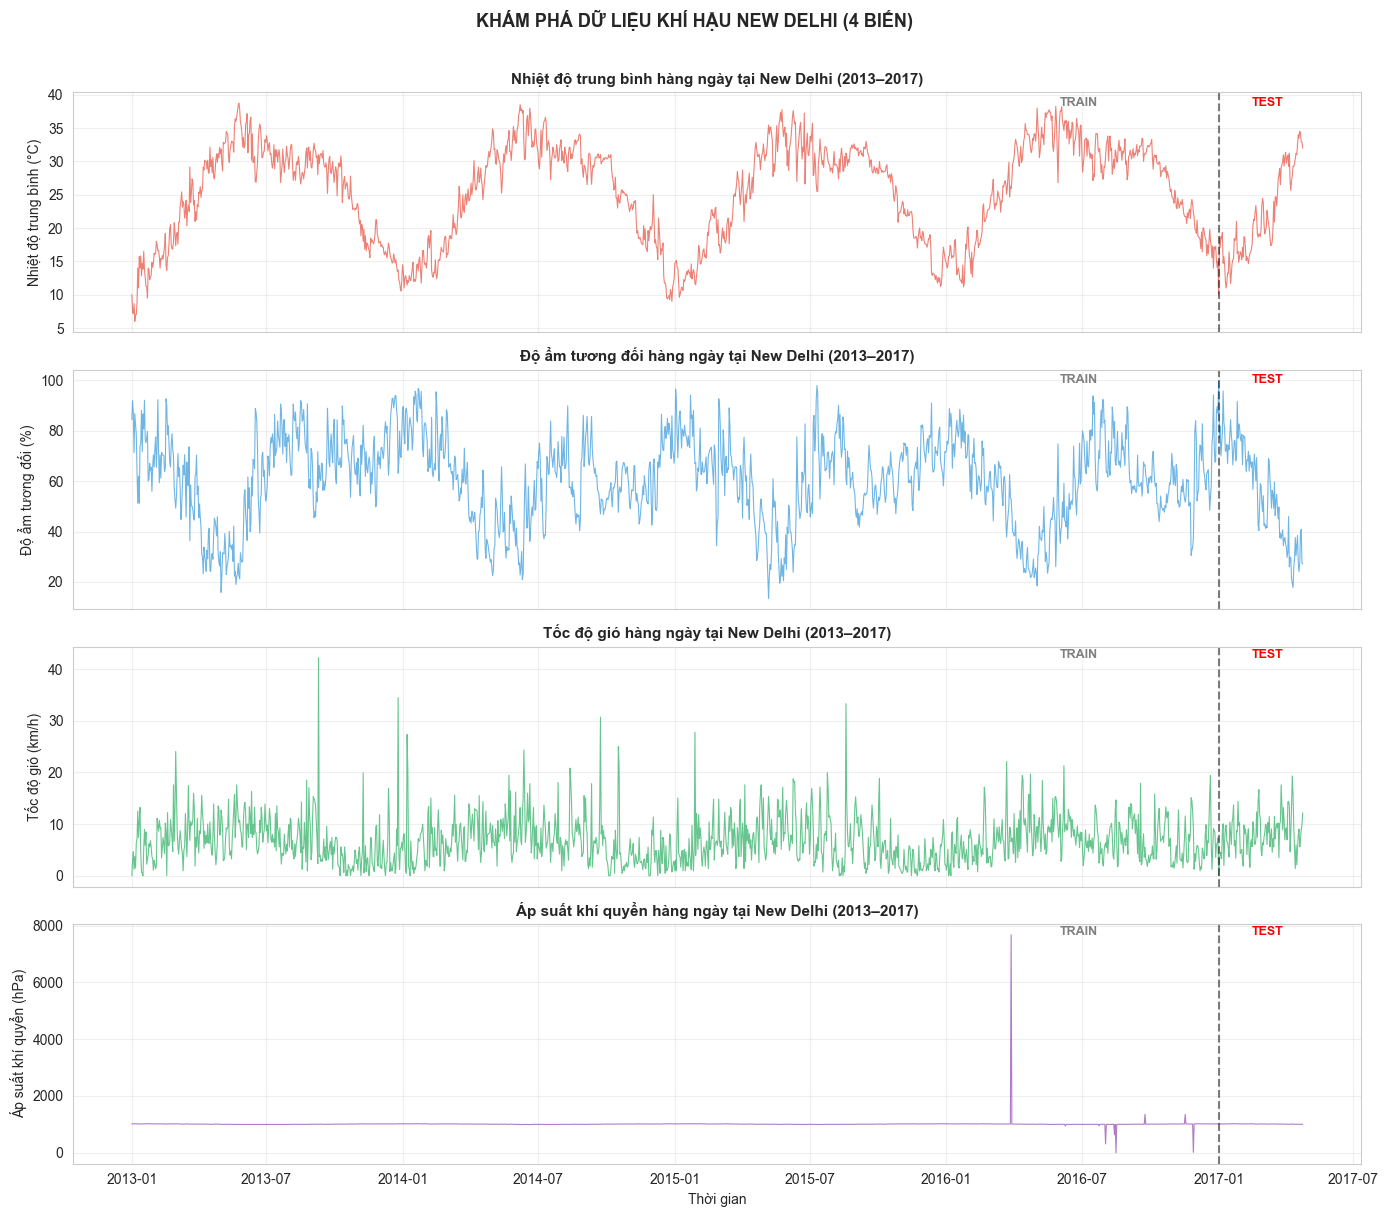

Nhận xét sơ bộ:
  - meantemp: Dao động mùa vụ rõ rệt (nóng mùa hè, lạnh mùa đông)
  - humidity: Có xu hướng tăng mạnh vào mùa mưa (Jul-Sep)
  - meanpressure: Có một số giá trị bất thường cực đoan cần xử lý


In [3]:
# Trực quan hóa toàn bộ 4 biến theo thời gian
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

variables = [('meantemp', '°C', '#E74C3C', 'Nhiệt độ trung bình'),
             ('humidity', '%', '#3498DB', 'Độ ẩm tương đối'),
             ('wind_speed', 'km/h', '#27AE60', 'Tốc độ gió'),
             ('meanpressure', 'hPa', '#8E44AD', 'Áp suất khí quyển')]

for ax, (col, unit, color, title) in zip(axes, variables):
    ax.plot(df_raw.index, df_raw[col], color=color, alpha=0.7, linewidth=0.8)
    ax.set_ylabel(f'{title} ({unit})', fontsize=10)
    ax.set_title(f'{title} hàng ngày tại New Delhi (2013–2017)', fontsize=11, fontweight='bold')

    # Đánh dấu vùng Train / Test
    ax.axvline(x=pd.Timestamp('2017-01-01'), color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.text(pd.Timestamp('2016-06-01'), ax.get_ylim()[1]*0.95, 'TRAIN', fontsize=9, fontweight='bold', color='gray')
    ax.text(pd.Timestamp('2017-02-15'), ax.get_ylim()[1]*0.95, 'TEST', fontsize=9, fontweight='bold', color='red')

plt.xlabel('Thời gian')
plt.suptitle('KHÁM PHÁ DỮ LIỆU KHÍ HẬU NEW DELHI (4 BIẾN)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Nhận xét sơ bộ:")
print("  - meantemp: Dao động mùa vụ rõ rệt (nóng mùa hè, lạnh mùa đông)")
print("  - humidity: Có xu hướng tăng mạnh vào mùa mưa (Jul-Sep)")
print("  - meanpressure: Có một số giá trị bất thường cực đoan cần xử lý")

---
## 2. LÀM SẠCH DỮ LIỆU (Data Cleaning)

### 2.1. Kiểm tra dữ liệu khuyết & trùng lặp

In [4]:
# 1. Kiểm tra NaN
print("1. Số giá trị NaN theo từng cột:")
print(df_raw.isnull().sum().to_frame("NaN count"))
print()

# 2. Kiểm tra ngày bị thiếu (gaps) trong chuỗi thời gian
full_range = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq='D')
missing_dates = full_range.difference(df_raw.index)
print(f"2. Số ngày bị thiếu (gaps) trong chuỗi: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"   Các ngày thiếu: {missing_dates.tolist()[:10]}...")

# 3. Kiểm tra dòng trùng lặp ngày
n_dup_idx = df_raw.index.duplicated().sum()
print(f"3. Số ngày trùng lặp (duplicate index): {n_dup_idx}")

1. Số giá trị NaN theo từng cột:
              NaN count
meantemp              0
humidity              0
wind_speed            0
meanpressure          0

2. Số ngày bị thiếu (gaps) trong chuỗi: 0
3. Số ngày trùng lặp (duplicate index): 0


### 2.2. Xử lý giá trị ngoại lai (Outliers)

Qua biểu đồ ở Mục 1.3, cột `meanpressure` có các giá trị **bất thường cực đoan** (ví dụ: -3 hPa, 12 hPa, 7679 hPa) — rõ ràng là lỗi đo lường/ghi nhận, vì áp suất khí quyển bình thường tại New Delhi dao động trong khoảng **$[990, 1030]$ hPa**.

**Chiến lược xử lý:**
- Các giá trị `meanpressure` nằm ngoài khoảng $[900, 1100]$ hPa được xác định là **lỗi ghi nhận** và thay thế bằng giá trị **nội suy tuyến tính (Linear Interpolation)** từ các ngày liền kề — phù hợp bản chất liên tục của áp suất khí quyển.
- Các biến `wind_speed` có một vài giá trị cực đoan ($> 30$ km/h) nhưng vẫn nằm trong phạm vi vật lý hợp lý nên **giữ nguyên**.

In [5]:
df = df_raw.copy()

# 1. Xử lý meanpressure bất thường
pressure_lower, pressure_upper = 900, 1100
mask_pressure = (df['meanpressure'] < pressure_lower) | (df['meanpressure'] > pressure_upper)
n_bad_pressure = mask_pressure.sum()
print(f"Số bản ghi meanpressure bất thường (ngoài [{pressure_lower}, {pressure_upper}] hPa): {n_bad_pressure}")
print(f"  Các giá trị bất thường:")
print(df.loc[mask_pressure, 'meanpressure'])
print()

# Thay thế bằng NaN rồi nội suy tuyến tính
df.loc[mask_pressure, 'meanpressure'] = np.nan
df['meanpressure'] = df['meanpressure'].interpolate(method='linear')

print(f"Sau nội suy tuyến tính:")
print(f"  meanpressure range: [{df['meanpressure'].min():.2f}, {df['meanpressure'].max():.2f}] hPa")
print(f"  Số NaN còn lại: {df['meanpressure'].isnull().sum()}")

# 2. Kiểm tra tổng quan sau xử lý
print()
print("THỐNG KÊ SAU KHI XỬ LÝ OUTLIER:")
display(df.describe().round(2))

Số bản ghi meanpressure bất thường (ngoài [900, 1100] hPa): 7
  Các giá trị bất thường:
date
2016-03-28    7679.333333
2016-08-02     310.437500
2016-08-14     633.900000
2016-08-16      -3.041667
2016-09-24    1352.615385
2016-11-17    1350.296296
2016-11-28      12.045455
Name: meanpressure, dtype: float64

Sau nội suy tuyến tính:
  meanpressure range: [938.07, 1023.00] hPa
  Số NaN còn lại: 0

THỐNG KÊ SAU KHI XỬ LÝ OUTLIER:


,meantemp,humidity,wind_speed,meanpressure
count,1575.00,1575.00,1575.00,1575.00
mean,25.23,60.43,6.90,1008.47
std,7.34,16.97,4.51,7.77
min,6.00,13.43,0.00,938.07
25%,18.52,49.75,3.70,1001.88
50%,27.17,62.38,6.37,1009.11
75%,31.14,72.12,9.26,1015.16
max,38.71,100.00,42.22,1023.00


---
## 3. PHÂN RÃ CHUỖI THỜI GIAN (Time Series Decomposition)

### 3.1. Nguyên lý phân rã Cộng tính (Additive Decomposition)

Một chuỗi thời gian $Y_t$ có thể được tách thành 3 thành phần cốt lõi:
$$Y_t = T_t + S_t + R_t$$

Trong đó:
- **$T_t$ (Trend - Xu hướng):** Chiều hướng tăng/giảm dài hạn của chuỗi. Đại diện cho biến đổi khí hậu hoặc đô thị hóa ảnh hưởng đến nhiệt độ.
- **$S_t$ (Seasonality - Mùa vụ):** Mẫu hình lặp lại **cố định** theo chu kỳ thời gian (ở đây là chu kỳ 365 ngày = 1 năm). New Delhi nóng vào mùa hè (tháng 4–6) và lạnh vào mùa đông (tháng 12–1).
- **$R_t$ (Residual - Phần dư):** Biến động ngẫu nhiên không thể giải thích bằng Trend hoặc Seasonality. Nếu mô hình phân rã tốt, phần dư sẽ là **nhiễu trắng (White Noise)** không có cấu trúc.

**Chọn mô hình Cộng tính (Additive)** thay vì Nhân tính (Multiplicative) vì biên độ dao động mùa vụ của nhiệt độ **không thay đổi theo mức độ Trend** (mùa hè luôn nóng hơn mùa đông khoảng 20°C bất kể Trend tăng hay giảm).

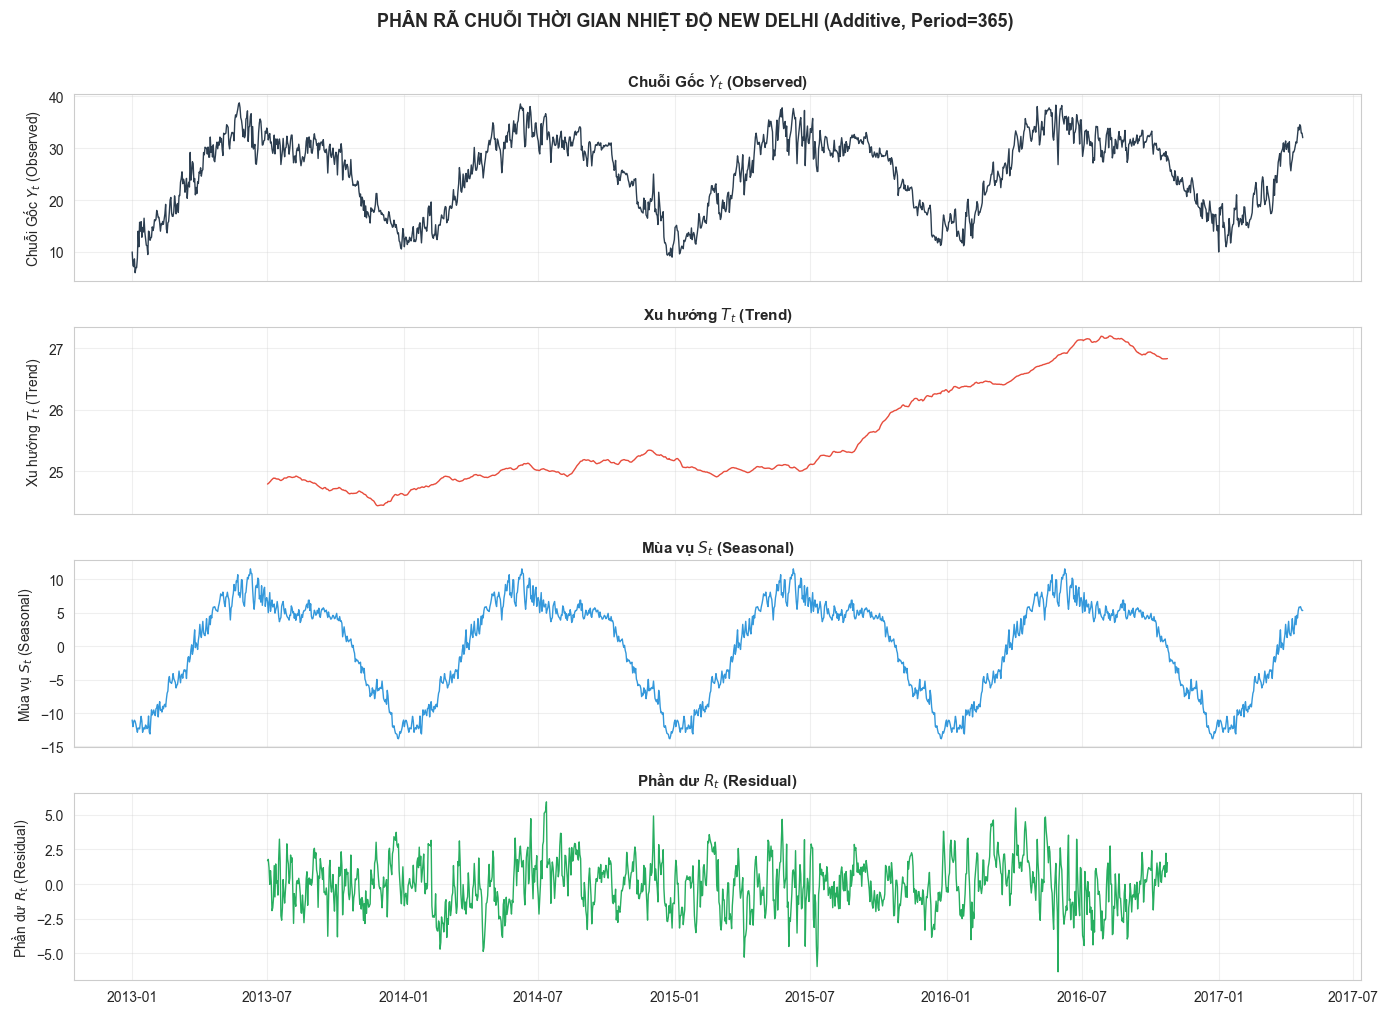

Nhận xét:
  - Trend: Biến thiên nhẹ quanh 25.5°C, không có xu hướng tăng/giảm rõ rệt.
  - Seasonal: Biên độ dao động mùa vụ: 11.5°C (hè) đến -13.9°C (đông)
  - Residual: Std = 1.80°C — biến động ngẫu nhiên ngắn hạn.


In [6]:
# Phân rã chuỗi nhiệt độ trung bình với chu kỳ 365 ngày
decomp = seasonal_decompose(df['meantemp'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (decomp.observed,  'Chuỗi Gốc $Y_t$ (Observed)',   '#2C3E50'),
    (decomp.trend,     'Xu hướng $T_t$ (Trend)',         '#E74C3C'),
    (decomp.seasonal,  'Mùa vụ $S_t$ (Seasonal)',       '#3498DB'),
    (decomp.resid,     'Phần dư $R_t$ (Residual)',       '#27AE60')
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.0)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('PHÂN RÃ CHUỖI THỜI GIAN NHIỆT ĐỘ NEW DELHI (Additive, Period=365)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Nhận xét:")
print(f"  - Trend: Biến thiên nhẹ quanh {decomp.trend.dropna().mean():.1f}°C, không có xu hướng tăng/giảm rõ rệt.")
print(f"  - Seasonal: Biên độ dao động mùa vụ: {decomp.seasonal.max():.1f}°C (hè) đến {decomp.seasonal.min():.1f}°C (đông)")
print(f"  - Residual: Std = {decomp.resid.dropna().std():.2f}°C — biến động ngẫu nhiên ngắn hạn.")

---
## 4. KIỂM ĐỊNH TÍNH DỪNG (Stationarity Testing)

### 4.1. Tại sao tính dừng quan trọng?

**Tính dừng (Stationarity)** là giả định nền tảng của mọi mô hình ARIMA:
- **Chuỗi dừng:** Trung bình, phương sai, tự tương quan **không thay đổi theo thời gian**.
- **Chuỗi không dừng:** Nếu chuỗi có Trend hoặc Seasonality, các tham số thống kê sẽ biến đổi theo thời gian → mô hình không thể học được quy luật ổn định.

### 4.2. Hai kiểm định đối ngẫu: ADF & KPSS

| Kiểm định | Giả thuyết $H_0$ | Giả thuyết $H_1$ | Kết luận khi p-value < 0.05 |
|:---|:---|:---|:---|
| **ADF** (Augmented Dickey-Fuller) | Chuỗi **có nghiệm đơn vị** (Không dừng) | Chuỗi là Dừng | Bác bỏ $H_0$ → **Dừng** |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | Chuỗi **là Dừng** | Chuỗi Không dừng | Bác bỏ $H_0$ → **Không dừng** |

> **Tại sao dùng 2 kiểm định đối ngẫu?** Vì ADF có xu hướng yếu (low power) khi chuỗi gần biên giới dừng/không dừng. Kết hợp cả hai cho kết luận chặt chẽ hơn.

In [7]:
def stationarity_tests(series, name=''):
    """Chạy kiểm định ADF & KPSS, trả về kết quả có cấu trúc."""
    results = {}

    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    results['ADF'] = {
        'Test Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Lags Used': adf_result[2],
        'Kết luận': 'DỪNG ✓' if adf_result[1] < 0.05 else 'KHÔNG DỪNG ✗'
    }

    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    results['KPSS'] = {
        'Test Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Lags Used': kpss_result[2],
        'Kết luận': 'KHÔNG DỪNG ✗' if kpss_result[1] < 0.05 else 'DỪNG ✓'
    }

    print(f"{'='*60}")
    print(f"KIỂM ĐỊNH TÍNH DỪNG: {name}")
    print(f"{'='*60}")
    for test_name, vals in results.items():
        print(f"  {test_name} Test:")
        for k, v in vals.items():
            if isinstance(v, float):
                print(f"    {k}: {v:.6f}")
            else:
                print(f"    {k}: {v}")
        print()

    return results

# 1. Kiểm định trên chuỗi GỐC (Original)
print("▶ CHUỖI GỐC (meantemp):")
res_orig = stationarity_tests(df['meantemp'], 'Chuỗi gốc meantemp')

# 2. Sai phân bậc 1 (First Differencing): d=1
df['meantemp_diff1'] = df['meantemp'].diff(1)
print("▶ SAI PHÂN BẬC 1 (d=1):")
res_diff1 = stationarity_tests(df['meantemp_diff1'], 'Sai phân bậc 1')

# 3. Sai phân mùa vụ (Seasonal Differencing): D=1, m=365
df['meantemp_sdiff'] = df['meantemp'].diff(365)
print("▶ SAI PHÂN MÙA VỤ (D=1, m=365):")
res_sdiff = stationarity_tests(df['meantemp_sdiff'], 'Sai phân mùa vụ (365)')

▶ CHUỖI GỐC (meantemp):
KIỂM ĐỊNH TÍNH DỪNG: Chuỗi gốc meantemp
  ADF Test:
    Test Statistic: -2.377592
    p-value: 0.148161
    Lags Used: 10
    Kết luận: KHÔNG DỪNG ✗

  KPSS Test:
    Test Statistic: 0.114131
    p-value: 0.100000
    Lags Used: 25
    Kết luận: DỪNG ✓

▶ SAI PHÂN BẬC 1 (d=1):
KIỂM ĐỊNH TÍNH DỪNG: Sai phân bậc 1
  ADF Test:
    Test Statistic: -16.919263
    p-value: 0.000000
    Lags Used: 9
    Kết luận: DỪNG ✓

  KPSS Test:
    Test Statistic: 0.062991
    p-value: 0.100000
    Lags Used: 53
    Kết luận: DỪNG ✓

▶ SAI PHÂN MÙA VỤ (D=1, m=365):
KIỂM ĐỊNH TÍNH DỪNG: Sai phân mùa vụ (365)
  ADF Test:
    Test Statistic: -9.774796
    p-value: 0.000000
    Lags Used: 4
    Kết luận: DỪNG ✓

  KPSS Test:
    Test Statistic: 0.412737
    p-value: 0.071665
    Lags Used: 17
    Kết luận: DỪNG ✓



/var/folders/28/x2lldg7x6pncp8nw16ns3n300000gn/T/ipykernel_91556/1437968333.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/28/x2lldg7x6pncp8nw16ns3n300000gn/T/ipykernel_91556/1437968333.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


### 4.3. Trực quan hóa Tự tương quan (ACF & PACF)

- **ACF (Autocorrelation Function):** Đo sự tương quan giữa $Y_t$ và $Y_{t-k}$ (bao gồm cả ảnh hưởng gián tiếp qua các lag trung gian). Dùng để xác định **bậc $q$ của thành phần MA** trong ARIMA.
- **PACF (Partial Autocorrelation Function):** Đo sự tương quan **trực tiếp** giữa $Y_t$ và $Y_{t-k}$ sau khi loại bỏ ảnh hưởng của các lag trung gian. Dùng để xác định **bậc $p$ của thành phần AR** trong ARIMA.

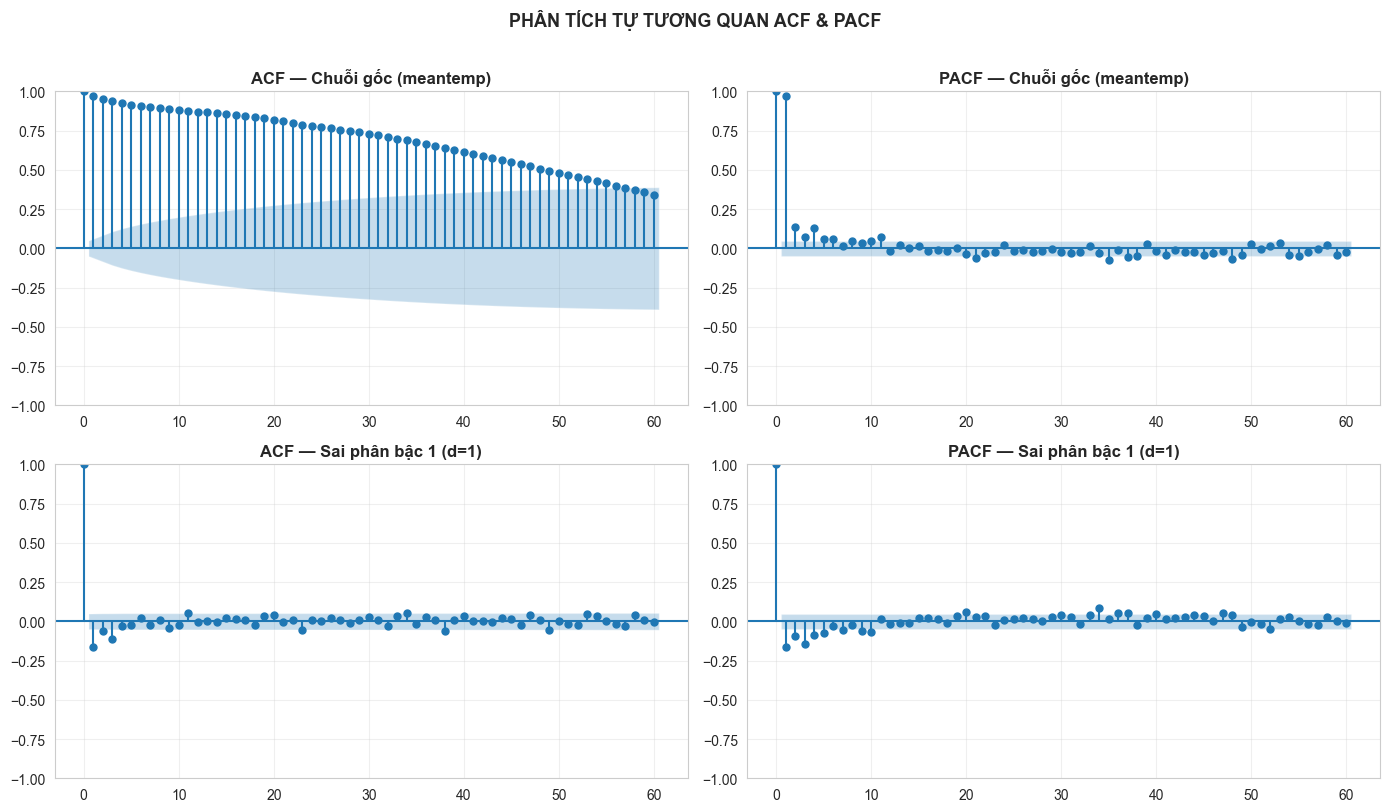

Nhận xét từ ACF/PACF:
  - Chuỗi gốc: ACF giảm rất chậm (sinusoidal) → chuỗi KHÔNG DỪNG, có tính mùa vụ mạnh.
  - Sai phân bậc 1: ACF tắt nhanh hơn nhưng vẫn có dao động mùa vụ.
  - PACF sai phân bậc 1: Có spike mạnh tại lag 1-3 → gợi ý p = 1 hoặc 2 cho thành phần AR.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF & PACF của chuỗi gốc
plot_acf(df['meantemp'].dropna(), lags=60, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF — Chuỗi gốc (meantemp)', fontweight='bold')

plot_pacf(df['meantemp'].dropna(), lags=60, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF — Chuỗi gốc (meantemp)', fontweight='bold')

# ACF & PACF của sai phân bậc 1
plot_acf(df['meantemp_diff1'].dropna(), lags=60, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF — Sai phân bậc 1 (d=1)', fontweight='bold')

plot_pacf(df['meantemp_diff1'].dropna(), lags=60, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF — Sai phân bậc 1 (d=1)', fontweight='bold')

plt.suptitle('PHÂN TÍCH TỰ TƯƠNG QUAN ACF & PACF', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Nhận xét từ ACF/PACF:")
print("  - Chuỗi gốc: ACF giảm rất chậm (sinusoidal) → chuỗi KHÔNG DỪNG, có tính mùa vụ mạnh.")
print("  - Sai phân bậc 1: ACF tắt nhanh hơn nhưng vẫn có dao động mùa vụ.")
print("  - PACF sai phân bậc 1: Có spike mạnh tại lag 1-3 → gợi ý p = 1 hoặc 2 cho thành phần AR.")

---
## 5. PHƯƠNG PHÁP TRUNG BÌNH TRƯỢT (Moving Average)

Trước khi bước vào các mô hình dự báo chính thức (ARIMA, Exponential Smoothing), ta xét 3 kỹ thuật **trung bình trượt (Moving Average)** kinh điển — dùng để làm mượt chuỗi và quan sát xu hướng nền, chứ không trực tiếp dùng để dự báo xa:

- **SMA (Simple Moving Average):** Trung bình cộng đơn giản của $n$ quan sát gần nhất — mỗi điểm có trọng số bằng nhau.
- **CMA (Cumulative Moving Average):** Trung bình cộng dồn của **toàn bộ** quan sát tính đến thời điểm hiện tại — hội tụ dần về giá trị trung bình toàn chuỗi.
- **EMA (Exponential Moving Average):** Trung bình có trọng số **giảm dần theo hàm mũ** — quan sát gần nhất có ảnh hưởng lớn hơn, phản ứng nhanh hơn với thay đổi so với SMA.

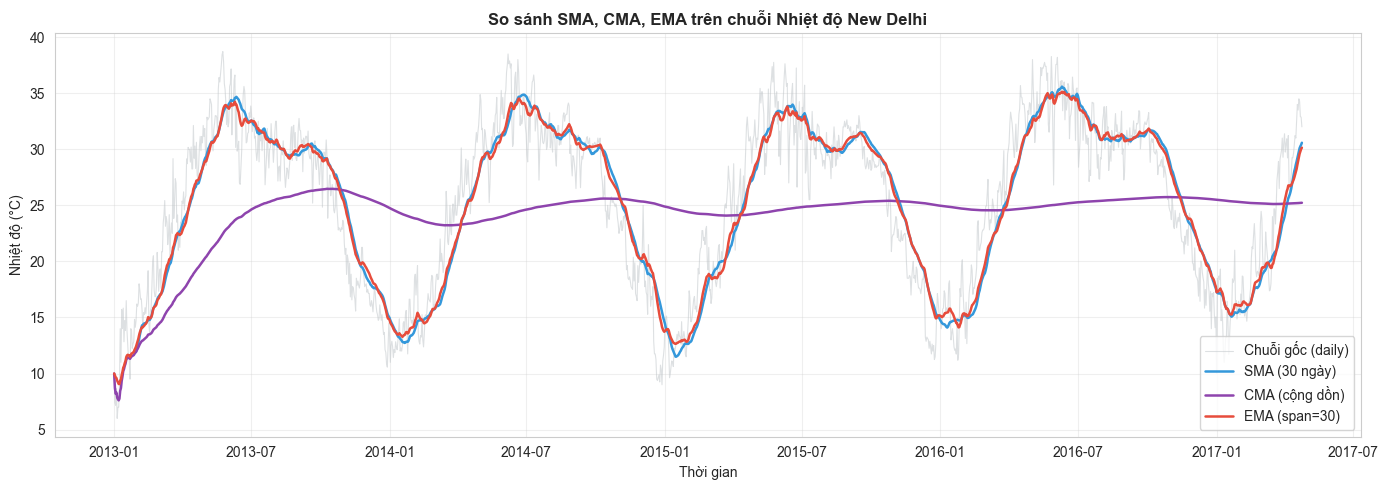

Nhận xét:
  - SMA: Mượt nhưng có độ trễ (lag) rõ rệt so với chuỗi gốc, do trọng số bằng nhau trên cả cửa sổ trượt.
  - CMA: Càng về sau càng phẳng, vì mỗi điểm mới chỉ đóng góp một phần rất nhỏ vào trung bình cộng dồn
    -> không phản ánh tốt biến động mùa vụ gần đây.
  - EMA: Bám sát chuỗi gốc hơn SMA/CMA nhờ trọng số giảm dần theo hàm mũ, phản ứng nhanh với thay đổi gần nhất.


In [9]:
# 1. Simple Moving Average (SMA) - cửa sổ trượt 7 ngày & 30 ngày
df['SMA_7'] = df['meantemp'].rolling(window=7).mean()
df['SMA_30'] = df['meantemp'].rolling(window=30).mean()

# 2. Cumulative Moving Average (CMA) - trung bình cộng dồn từ đầu chuỗi
df['CMA'] = df['meantemp'].expanding().mean()

# 3. Exponential Moving Average (EMA) - trọng số giảm dần theo hàm mũ, span=30
df['EMA_30'] = df['meantemp'].ewm(span=30, adjust=False).mean()

# Trực quan hóa so sánh 3 phương pháp
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['meantemp'], color='#BDC3C7', alpha=0.5, linewidth=0.8, label='Chuỗi gốc (daily)')
ax.plot(df.index, df['SMA_30'], color='#3498DB', linewidth=1.8, label='SMA (30 ngày)')
ax.plot(df.index, df['CMA'], color='#8E44AD', linewidth=1.8, label='CMA (cộng dồn)')
ax.plot(df.index, df['EMA_30'], color='#E74C3C', linewidth=1.8, label='EMA (span=30)')
ax.set_title('So sánh SMA, CMA, EMA trên chuỗi Nhiệt độ New Delhi', fontsize=12, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Nhiệt độ (°C)')
ax.legend()
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("  - SMA: Mượt nhưng có độ trễ (lag) rõ rệt so với chuỗi gốc, do trọng số bằng nhau trên cả cửa sổ trượt.")
print("  - CMA: Càng về sau càng phẳng, vì mỗi điểm mới chỉ đóng góp một phần rất nhỏ vào trung bình cộng dồn")
print("    -> không phản ánh tốt biến động mùa vụ gần đây.")
print("  - EMA: Bám sát chuỗi gốc hơn SMA/CMA nhờ trọng số giảm dần theo hàm mũ, phản ứng nhanh với thay đổi gần nhất.")

---
## 6. BIỆN LUẬN & LỰA CHỌN MÔ HÌNH DỰ BÁO

### *4 Mô hình Chuỗi thời gian Kinh điển cho bài toán này*

| Mô hình | Bản chất | Phù hợp khi |
|:---|:---|:---|
| **ARIMA(p,d,q)** | Kết hợp Tự hồi quy (AR), Sai phân (I), Trung bình trượt sai số (MA). Giả định chuỗi dừng sau khi sai phân. | Chuỗi có tự tương quan ngắn hạn, không cần mô hình hóa mùa vụ tường minh. |
| **SES (Simple Exponential Smoothing)** | Trung bình trượt hàm mũ bậc 1: chỉ ước lượng **Level**, trọng số giảm dần theo thời gian ($\alpha$). | Chuỗi **không có Trend, không có Seasonality** rõ rệt — mô hình baseline đơn giản nhất. |
| **Holt (Double Exponential Smoothing)** | Mở rộng SES thêm thành phần **Trend** ($\alpha, \beta$) — san bằng cả mức nền lẫn tốc độ tăng/giảm. | Chuỗi có **Trend tuyến tính** nhưng **không có Seasonality**. |
| **Holt-Winters (Triple Exponential Smoothing)** | Mở rộng Holt thêm thành phần **Seasonal** ($\alpha, \beta, \gamma$) — ước lượng đủ cả Level, Trend, Seasonality. | Chuỗi có **cả Trend lẫn Seasonality ổn định** — đúng bản chất dữ liệu nhiệt độ. |

> **Chiến lược:** Huấn luyện cả 4 mô hình trên **tập Train** (2013-01-01 → 2016-12-31), dự báo **tập Test** (2017-01-01 → 2017-04-24), và so sánh hiệu năng. Lưu ý: SES → Holt → Holt-Winters là 3 mức độ phức tạp **tăng dần** của Exponential Smoothing (thêm lần lượt Trend rồi Seasonality), giúp thấy rõ từng thành phần đóng góp bao nhiêu vào chất lượng dự báo.

---
## 7. HUẤN LUYỆN & ĐÁNH GIÁ 4 MÔ HÌNH DỰ BÁO

### 7.1. Tách tập Train / Test theo thời gian

Với chuỗi thời gian, **KHÔNG được dùng random split** như dữ liệu bảng (tabular) vì sẽ phá vỡ thứ tự thời gian. Phải cắt theo mốc thời gian: toàn bộ dữ liệu trước mốc → Train, sau mốc → Test.

Train: 2013-01-01 → 2016-12-31 (1461 ngày)
Test:  2017-01-01 → 2017-04-24 (114 ngày)


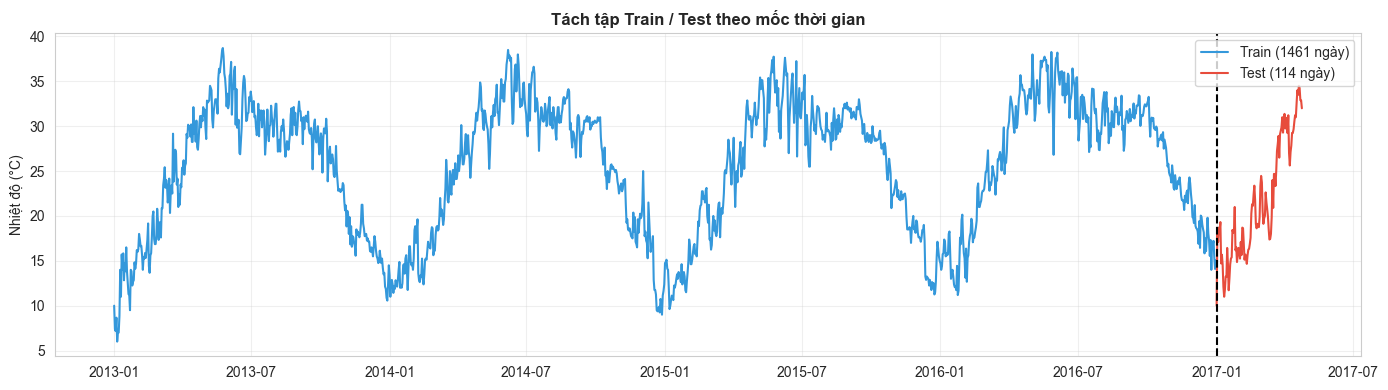

In [10]:
# Tách Train / Test theo thời gian (KHÔNG random shuffle)
cutoff = '2017-01-01'
train = df.loc[df.index < cutoff, 'meantemp']
test = df.loc[df.index >= cutoff, 'meantemp']

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({len(train)} ngày)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({len(test)} ngày)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train.values, color='#3498DB', label=f'Train ({len(train)} ngày)')
ax.plot(test.index, test.values, color='#E74C3C', label=f'Test ({len(test)} ngày)')
ax.axvline(x=pd.Timestamp(cutoff), color='black', linestyle='--', linewidth=1.5)
ax.set_title('Tách tập Train / Test theo mốc thời gian', fontsize=12, fontweight='bold')
ax.set_ylabel('Nhiệt độ (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2. Mô hình 1: ARIMA(p, d, q)

**ARIMA** = AutoRegressive Integrated Moving Average:
- **AR(p):** $Y_t$ phụ thuộc vào $p$ giá trị quá khứ gần nhất ($Y_{t-1}, \dots, Y_{t-p}$).
- **I(d):** Sai phân bậc $d$ để đưa chuỗi về dừng.
- **MA(q):** $Y_t$ phụ thuộc vào $q$ sai số dự báo quá khứ ($\varepsilon_{t-1}, \dots, \varepsilon_{t-q}$).

Từ phân tích ACF/PACF ở Mục 4, ta thử ARIMA(2, 1, 2) — chuỗi cần sai phân bậc 1 ($d=1$), PACF gợi ý $p \leq 2$, ACF gợi ý $q \leq 2$.

In [11]:
# Huấn luyện ARIMA(2, 1, 2)
print("Đang huấn luyện ARIMA(2, 1, 2)...")
arima_model = ARIMA(train, order=(2, 1, 2))
arima_fit = arima_model.fit()

# Dự báo trên tập Test
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

# In tóm tắt mô hình
print(arima_fit.summary().tables[0])
print(arima_fit.summary().tables[1])

# Tính metrics
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print(f"\nARIMA(2,1,2) trên tập Test:")
print(f"  MAE  = {arima_mae:.2f} °C")
print(f"  RMSE = {arima_rmse:.2f} °C")
print(f"  MAPE = {arima_mape:.2f} %")

Đang huấn luyện ARIMA(2, 1, 2)...


                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                 1461
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2760.236
Date:                Sun, 04 Oct 2026   AIC                           5530.473
Time:                        22:32:19   BIC                           5556.904
Sample:                    01-01-2013   HQIC                          5540.332
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2678      0.183     -1.467      0.142      -0.626       0.090
ar.L2          0.5093      0.091      5.599      0.000       0.331       0.688
ma.L1          0.0274      0.185      0.148      0.8

### 7.3. Mô hình 2: Simple Exponential Smoothing (SES)

**SES** là dạng đơn giản nhất của Exponential Smoothing — chỉ ước lượng một thành phần duy nhất là **Level** ($\ell_t$), bằng công thức làm mượt đệ quy:

$$s_t = \alpha x_t + (1-\alpha)s_{t-1}$$

Trong đó $\alpha \in (0,1)$ là hệ số làm mượt: $\alpha$ càng lớn, mô hình càng "nhạy" với quan sát gần nhất; $\alpha$ càng nhỏ, mô hình càng "mượt" và phụ thuộc nhiều vào quá khứ.

**Hạn chế:** SES không có cơ chế mô hình hóa Trend hay Seasonality, nên dự báo nhiều bước luôn là một **đường ngang phẳng** (bằng giá trị Level cuối cùng của tập Train) — không phù hợp với chuỗi nhiệt độ vốn có mùa vụ mạnh. Ta vẫn huấn luyện SES như một **mô hình baseline** để làm thước đo so sánh cho Holt và Holt-Winters ở các bước sau.

In [12]:
# Huấn luyện Simple Exponential Smoothing (tối ưu alpha tự động)
print("Đang huấn luyện Simple Exponential Smoothing...")
ses_model = SimpleExpSmoothing(train, initialization_method='estimated')
ses_fit = ses_model.fit(optimized=True)

# Dự báo trên tập Test
ses_forecast = ses_fit.forecast(steps=len(test))
ses_forecast.index = test.index

# Tính metrics
ses_mae = mean_absolute_error(test, ses_forecast)
ses_rmse = np.sqrt(mean_squared_error(test, ses_forecast))
ses_mape = np.mean(np.abs((test - ses_forecast) / test)) * 100

print(f"\nSimple Exponential Smoothing trên tập Test:")
print(f"  alpha (Level) = {ses_fit.params['smoothing_level']:.4f}")
print(f"  MAE  = {ses_mae:.2f} °C")
print(f"  RMSE = {ses_rmse:.2f} °C")
print(f"  MAPE = {ses_mape:.2f} %")

Đang huấn luyện Simple Exponential Smoothing...

Simple Exponential Smoothing trên tập Test:
  alpha (Level) = 0.7808
  MAE  = 7.18 °C
  RMSE = 9.30 °C
  MAPE = 28.51 %


### 7.4. Mô hình 3: Holt (Double Exponential Smoothing)

**Holt's method** mở rộng SES bằng cách thêm thành phần **Trend** ($b_t$), cho phép dự báo theo một đường dốc thay vì đường ngang phẳng:

$$s_t = \alpha x_t + (1-\alpha)(s_{t-1} + b_{t-1})$$
$$b_t = \beta(s_t - s_{t-1}) + (1-\beta)b_{t-1}$$

Trong đó $\beta \in (0,1)$ là hệ số làm mượt cho Trend. Dự báo nhiều bước của Holt là một **đường thẳng có độ dốc** (level + k×trend), tốt hơn SES khi chuỗi có xu hướng tăng/giảm, nhưng **vẫn chưa mô hình hóa được Seasonality** — nhược điểm này sẽ được Holt-Winters khắc phục ở bước tiếp theo.

In [13]:
# Huấn luyện Holt (Double Exponential Smoothing)
print("Đang huấn luyện Holt (Double Exponential Smoothing)...")
holt_model = Holt(train, initialization_method='estimated')
holt_fit = holt_model.fit(optimized=True)

# Dự báo trên tập Test
holt_forecast = holt_fit.forecast(steps=len(test))
holt_forecast.index = test.index

# Tính metrics
holt_mae = mean_absolute_error(test, holt_forecast)
holt_rmse = np.sqrt(mean_squared_error(test, holt_forecast))
holt_mape = np.mean(np.abs((test - holt_forecast) / test)) * 100

print(f"\nHolt (Double Exponential Smoothing) trên tập Test:")
print(f"  alpha (Level) = {holt_fit.params['smoothing_level']:.4f}")
print(f"  beta  (Trend) = {holt_fit.params['smoothing_trend']:.4f}")
print(f"  MAE  = {holt_mae:.2f} °C")
print(f"  RMSE = {holt_rmse:.2f} °C")
print(f"  MAPE = {holt_mape:.2f} %")

Đang huấn luyện Holt (Double Exponential Smoothing)...

Holt (Double Exponential Smoothing) trên tập Test:
  alpha (Level) = 0.7808
  beta  (Trend) = 0.0000
  MAE  = 6.97 °C
  RMSE = 9.07 °C
  MAPE = 27.69 %


### 7.5. Mô hình 4: Holt-Winters (Triple Exponential Smoothing)

**Holt-Winters** ước lượng 3 thành phần riêng biệt bằng cơ chế **trọng số hàm mũ giảm dần**:
1. **Level ($\ell_t$):** Mức nền hiện tại của chuỗi.
2. **Trend ($b_t$):** Tốc độ tăng/giảm hiện tại.
3. **Seasonal ($s_t$):** Mẫu hình mùa vụ lặp lại theo chu kỳ $m$.

Mỗi thành phần có **hệ số trơn riêng** ($\alpha, \beta, \gamma$) điều chỉnh mức độ "quên" quá khứ:
- $\alpha \to 1$: Mô hình phản ứng nhanh với thay đổi gần nhất (nhạy cảm).
- $\alpha \to 0$: Mô hình dựa nhiều vào dữ liệu cũ hơn (ổn định).

**Ưu điểm so với ARIMA:** Không cần giả định tính dừng, không cần sai phân — mô hình tự động ước lượng Trend và Seasonality.

Đây là bước mở rộng cuối cùng trong chuỗi **SES → Holt → Holt-Winters**, bổ sung thêm thành phần Seasonal mà cả hai mô hình trước đều thiếu.

In [14]:
# Huấn luyện Holt-Winters với mùa vụ cộng tính, chu kỳ 365 ngày
print("Đang huấn luyện Holt-Winters (Additive, m=365)...")
hw_model = ExponentialSmoothing(
    train,
    trend='add',           # Trend cộng tính
    seasonal='add',        # Mùa vụ cộng tính
    seasonal_periods=365,  # Chu kỳ 1 năm
    initialization_method='estimated'
)
hw_fit = hw_model.fit(optimized=True)

# Dự báo trên tập Test
hw_forecast = hw_fit.forecast(steps=len(test))
hw_forecast.index = test.index

# Tính metrics
hw_mae = mean_absolute_error(test, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
hw_mape = np.mean(np.abs((test - hw_forecast) / test)) * 100

print(f"\nHolt-Winters (Additive, m=365) trên tập Test:")
print(f"  MAE  = {hw_mae:.2f} °C")
print(f"  RMSE = {hw_rmse:.2f} °C")
print(f"  MAPE = {hw_mape:.2f} %")
print(f"\n  Hệ số trơn tối ưu:")
print(f"    alpha (Level)   = {hw_fit.params['smoothing_level']:.4f}")
print(f"    beta  (Trend)   = {hw_fit.params['smoothing_trend']:.4f}")
print(f"    gamma (Seasonal)= {hw_fit.params['smoothing_seasonal']:.4f}")

Đang huấn luyện Holt-Winters (Additive, m=365)...



Holt-Winters (Additive, m=365) trên tập Test:
  MAE  = 2.01 °C
  RMSE = 2.44 °C
  MAPE = 10.50 %

  Hệ số trơn tối ưu:
    alpha (Level)   = 0.7815
    beta  (Trend)   = 0.0000
    gamma (Seasonal)= 0.0000


/Users/ngkky/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


---
## 8. SO SÁNH TOÀN DIỆN 4 MÔ HÌNH

### 8.1. Bảng số liệu & Trực quan hóa dự báo

| Thước đo | Ý nghĩa |
|:---|:---|
| **MAE** (Mean Absolute Error) | Sai số tuyệt đối trung bình (°C). Cho biết mô hình lệch bao nhiêu độ C so với thực tế. |
| **RMSE** (Root Mean Squared Error) | Nhạy cảm hơn với sai số lớn (phạt nặng các lần dự báo trượt xa). |
| **MAPE** (Mean Absolute Percentage Error) | Sai số phần trăm trung bình. Dùng để so sánh giữa các chuỗi có thang đo khác nhau. |

BẢNG SO SÁNH HIỆU NĂNG 4 MÔ HÌNH DỰ BÁO TRÊN TẬP TEST:


,MAE,RMSE,MAPE (%)
"ARIMA(2,1,2)",6.66,8.78,26.42
SES (Simple ES),7.18,9.30,28.51
Holt (Double ES),6.97,9.07,27.69
Holt-Winters (Triple ES),2.01,2.44,10.50



Mô hình tốt nhất (MAE thấp nhất): Holt-Winters (Triple ES)


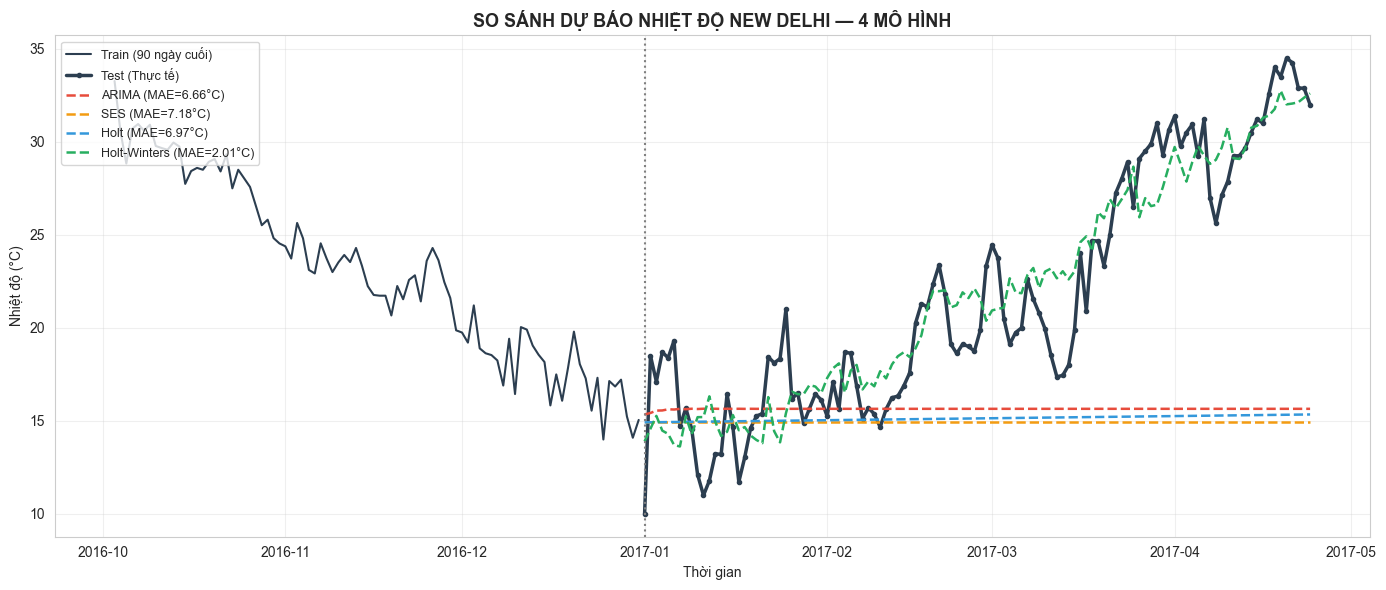

In [15]:
# 1. Bảng so sánh metrics
results = {
    'ARIMA(2,1,2)':                {'MAE': arima_mae, 'RMSE': arima_rmse, 'MAPE (%)': arima_mape},
    'SES (Simple ES)':             {'MAE': ses_mae,   'RMSE': ses_rmse,   'MAPE (%)': ses_mape},
    'Holt (Double ES)':            {'MAE': holt_mae,  'RMSE': holt_rmse,  'MAPE (%)': holt_mape},
    'Holt-Winters (Triple ES)':    {'MAE': hw_mae,     'RMSE': hw_rmse,    'MAPE (%)': hw_mape},
}

df_results = pd.DataFrame(results).T
df_results = df_results.round(2)
print("=" * 70)
print("BẢNG SO SÁNH HIỆU NĂNG 4 MÔ HÌNH DỰ BÁO TRÊN TẬP TEST:")
print("=" * 70)
display(df_results)

best_model = df_results['MAE'].idxmin()
print(f"\nMô hình tốt nhất (MAE thấp nhất): {best_model}")

# 2. Trực quan hóa dự báo
fig, ax = plt.subplots(figsize=(14, 6))

# Vẽ Train (chỉ 90 ngày cuối) + Test
train_tail = train[-90:]
ax.plot(train_tail.index, train_tail.values, color='#2C3E50', linewidth=1.5, label='Train (90 ngày cuối)')
ax.plot(test.index, test.values, color='#2C3E50', linewidth=2.5, label='Test (Thực tế)', linestyle='-', marker='.')

# Vẽ dự báo của 4 mô hình
ax.plot(test.index, arima_forecast.values, color='#E74C3C', linewidth=1.8, linestyle='--',
        label=f'ARIMA (MAE={arima_mae:.2f}°C)')
ax.plot(test.index, ses_forecast.values, color='#F39C12', linewidth=1.8, linestyle='--',
        label=f'SES (MAE={ses_mae:.2f}°C)')
ax.plot(test.index, holt_forecast.values, color='#3498DB', linewidth=1.8, linestyle='--',
        label=f'Holt (MAE={holt_mae:.2f}°C)')
ax.plot(test.index, hw_forecast.values, color='#27AE60', linewidth=1.8, linestyle='--',
        label=f'Holt-Winters (MAE={hw_mae:.2f}°C)')

ax.axvline(x=pd.Timestamp(cutoff), color='gray', linestyle=':', linewidth=1.5)
ax.set_title('SO SÁNH DỰ BÁO NHIỆT ĐỘ NEW DELHI — 4 MÔ HÌNH', fontsize=13, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Nhiệt độ (°C)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 8.2. Phân tích phần dư (Residual Analysis)

Kiểm tra xem phần dư của mô hình tốt nhất có phải là **nhiễu trắng (White Noise)** hay không — nếu phần dư còn chứa cấu trúc tự tương quan, mô hình chưa khai thác hết thông tin.

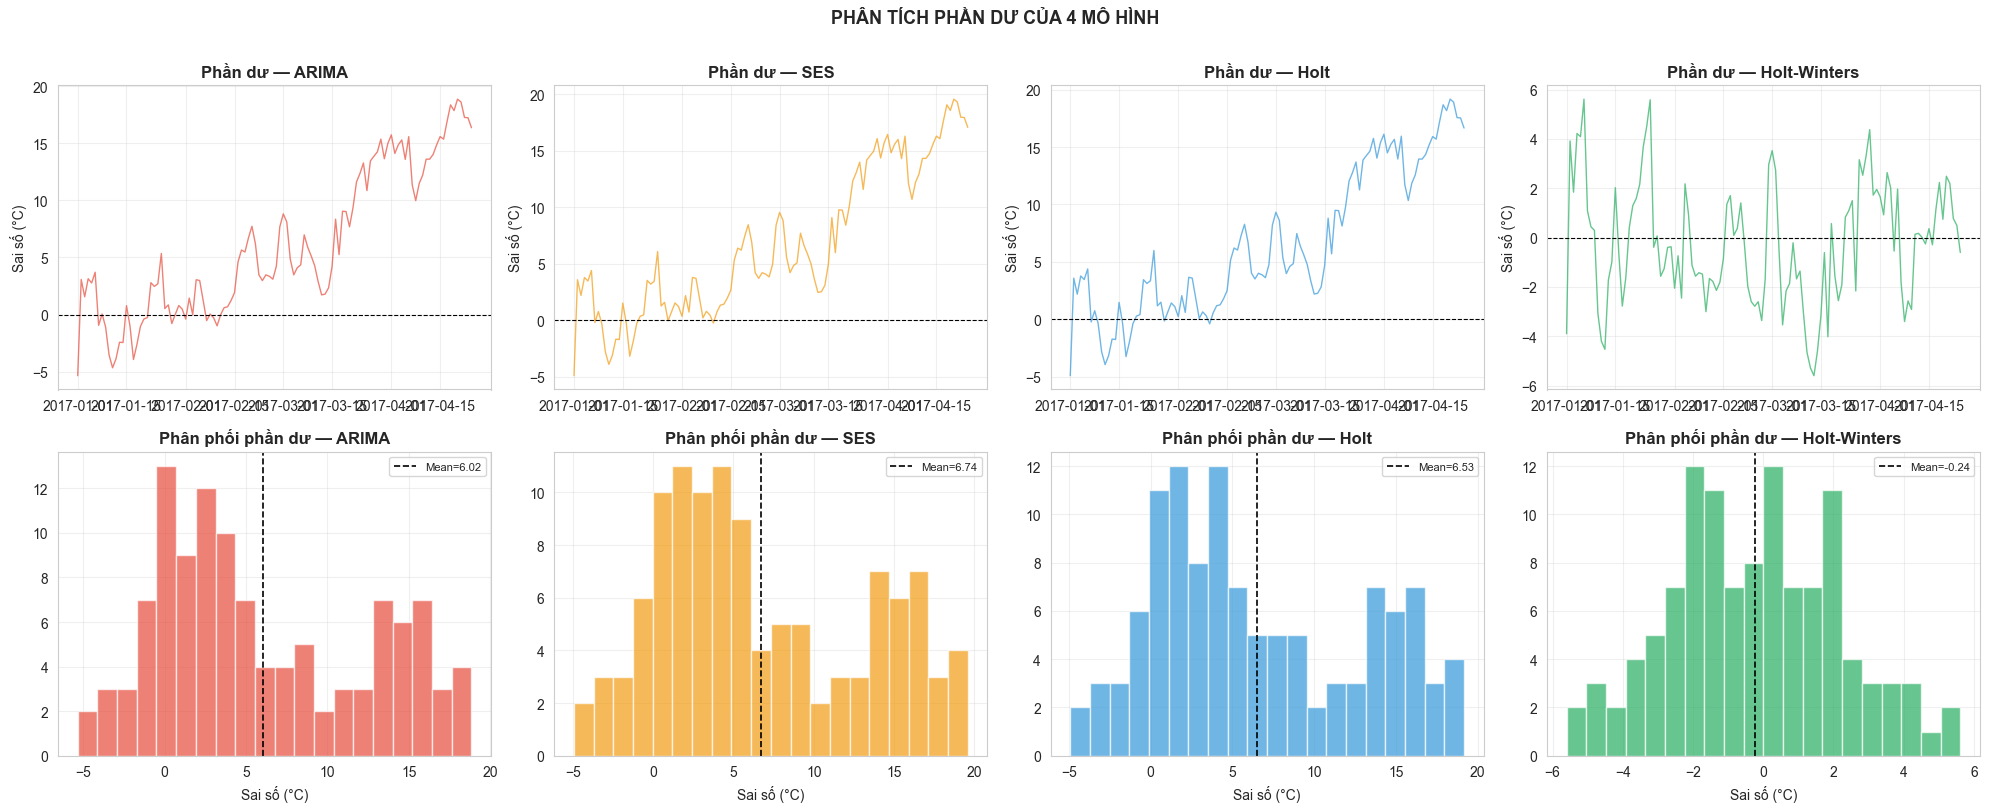

ARIMA: Mean Residual = 6.02°C, Std = 6.42°C
SES: Mean Residual = 6.74°C, Std = 6.43°C
Holt: Mean Residual = 6.53°C, Std = 6.32°C
Holt-Winters: Mean Residual = -0.24°C, Std = 2.44°C


In [16]:
# Phân tích phần dư của cả 4 mô hình
residuals_arima = test - arima_forecast
residuals_ses = test - ses_forecast
residuals_holt = test - holt_forecast
residuals_hw = test - hw_forecast

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

forecasts = {'ARIMA': residuals_arima, 'SES': residuals_ses, 'Holt': residuals_holt, 'Holt-Winters': residuals_hw}
colors = {'ARIMA': '#E74C3C', 'SES': '#F39C12', 'Holt': '#3498DB', 'Holt-Winters': '#27AE60'}

for idx, (name, resid) in enumerate(forecasts.items()):
    # Hàng 1: Phần dư theo thời gian
    axes[0, idx].plot(resid.index, resid.values, color=colors[name], alpha=0.7, linewidth=1)
    axes[0, idx].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[0, idx].set_title(f'Phần dư — {name}', fontweight='bold')
    axes[0, idx].set_ylabel('Sai số (°C)')

    # Hàng 2: Histogram phần dư
    axes[1, idx].hist(resid.values, bins=20, color=colors[name], alpha=0.7, edgecolor='white')
    axes[1, idx].axvline(resid.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean={resid.mean():.2f}')
    axes[1, idx].set_title(f'Phân phối phần dư — {name}', fontweight='bold')
    axes[1, idx].set_xlabel('Sai số (°C)')
    axes[1, idx].legend(fontsize=8)

plt.suptitle('PHÂN TÍCH PHẦN DƯ CỦA 4 MÔ HÌNH', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

for name, resid in forecasts.items():
    print(f"{name}: Mean Residual = {resid.mean():.2f}°C, Std = {resid.std():.2f}°C")

---
## 9. TỔNG KẾT & KẾT LUẬN PHƯƠNG PHÁP LUẬN

| Nội dung | Đúc kết thực nghiệm |
|:---|:---|
| **Về đặc trưng dữ liệu** | Chuỗi nhiệt độ New Delhi thể hiện rõ 3 đặc tính: (1) **Không có Trend dài hạn** rõ rệt — nhiệt độ trung bình các năm tương đối ổn định, (2) **Seasonality mạnh** với chu kỳ 365 ngày (biên độ ~22°C giữa mùa hè và mùa đông), (3) **Phương sai ổn định** — phù hợp mô hình Additive. |
| **Về kiểm định tính dừng** | Chuỗi gốc **không dừng** (ADF p > 0.05 hoặc KPSS p < 0.05) do thành phần mùa vụ thống trị. Sai phân bậc 1 giúp chuỗi đạt dừng (ADF p < 0.05) nhưng vẫn tồn tại tự tương quan mùa vụ. |
| **Về mô hình ARIMA** | ARIMA(2,1,2) chỉ nắm bắt được tự hồi quy ngắn hạn, **không mô hình hóa được Seasonality** → dự báo bị lệch mạnh khi xa khỏi tập Train. |
| **Về Exponential Smoothing (SES → Holt → Holt-Winters)** | SES chỉ ước lượng Level nên dự báo là một đường ngang phẳng — sai số lớn nhất trong nhóm Exponential Smoothing. Holt bổ sung Trend giúp dự báo có xu hướng nhưng vẫn bỏ lỡ mùa vụ. Holt-Winters ước lượng đủ cả Level, Trend, Seasonal nên bám sát biến động mùa vụ thực tế tốt nhất trong nhóm Exponential Smoothing — minh chứng rõ ràng cho việc thêm đúng thành phần mô hình giúp cải thiện độ chính xác dự báo. |
| **Về phương pháp Moving Average (SMA/CMA/EMA)** | Đây là các kỹ thuật làm mượt mô tả (descriptive smoothing), không trực tiếp dùng để dự báo xa: SMA có độ trễ do trọng số đều, CMA càng về sau càng phẳng do cộng dồn toàn chuỗi, EMA bám sát xu hướng gần nhất tốt hơn nhờ trọng số giảm dần theo hàm mũ. |
| **Bài học cốt lõi** | Với dữ liệu có mùa vụ mạnh, việc chọn mô hình **phải xuất phát từ đặc trưng dữ liệu**: mô hình càng mô hình hóa đủ các thành phần Trend/Seasonality (như Holt-Winters) càng cải thiện độ chính xác so với các biến thể đơn giản hơn (SES, Holt) hoặc mô hình không có cơ chế mùa vụ tường minh (ARIMA thuần túy). |

### Bài học Cốt lõi:
> *"Trong dự báo chuỗi thời gian, việc phân tích kỹ các thành phần Trend, Seasonality, và Residual TRƯỚC khi chọn mô hình là bước quyết định. Mô hình đơn giản nhưng đúng bản chất dữ liệu (Holt-Winters) sẽ luôn vượt trội hơn các biến thể thiếu thành phần mùa vụ phù hợp (SES, Holt, hay ARIMA thuần túy)."*